In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tawsifurrahman/covid19-radiography-database")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'covid19-radiography-database' dataset.
Path to dataset files: /kaggle/input/covid19-radiography-database


In [2]:
!pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 19.2 MB/s eta 0:00:00


In [3]:
import os
import tqdm
import cv2
import numpy as np
def load_data_Set():
  levels = ['Normal', 'COVID', 'Lung_Opacity', 'Viral Pneumonia']
  class_names={levels:i for i,levels in enumerate(levels)}
  data_path='/kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset'
  all_images=[]
  labels=[]


  for level in levels:
    label=class_names[level]
    folder_path=os.path.join(data_path,level,'images')
    images_files=os.listdir(folder_path)

    #load images
    print(f'loading {level}')
    for image in tqdm.tqdm(images_files):
      img_path=os.path.join(folder_path,image)
      #image processing
      img=cv2.imread(img_path)
      if img is None:
        print(f'failed to read : {img_path}')
        continue

      img=cv2.cvtColor(img,cv2.COLOR_RGB2GRAY)
      img=cv2.resize(img,(100,100))
      img=np.expand_dims(img,axis=-1)

      all_images.append(img)
      labels.append(label)


  #convert to array
  all_images=np.array(all_images,dtype=np.float32)
  labels=np.array(labels,dtype='int32')
# normalization
  all_images= all_images/255.0


  return all_images,labels

In [4]:
(images,labels)=load_data_Set()

loading Normal


100%|██████████| 10192/10192 [01:48<00:00, 93.87it/s]


loading COVID


100%|██████████| 3616/3616 [00:37<00:00, 97.13it/s] 


loading Lung_Opacity


100%|██████████| 6012/6012 [01:00<00:00, 99.42it/s] 


loading Viral Pneumonia


100%|██████████| 1345/1345 [00:15<00:00, 88.55it/s]


In [5]:
from sklearn.model_selection import train_test_split
#spliting data to train and test
train_images, test_images, train_labels, test_labels = train_test_split(
    images,
    labels,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print(f'count train images : {train_images.shape}')
print(f'count train labels : {train_labels.shape}')
print(f'count test images : {test_images.shape}')
print(f'count test labels : {test_labels.shape}')

count train images : (16932, 100, 100, 1)
count train labels : (16932,)
count test images : (4233, 100, 100, 1)
count test labels : (4233,)


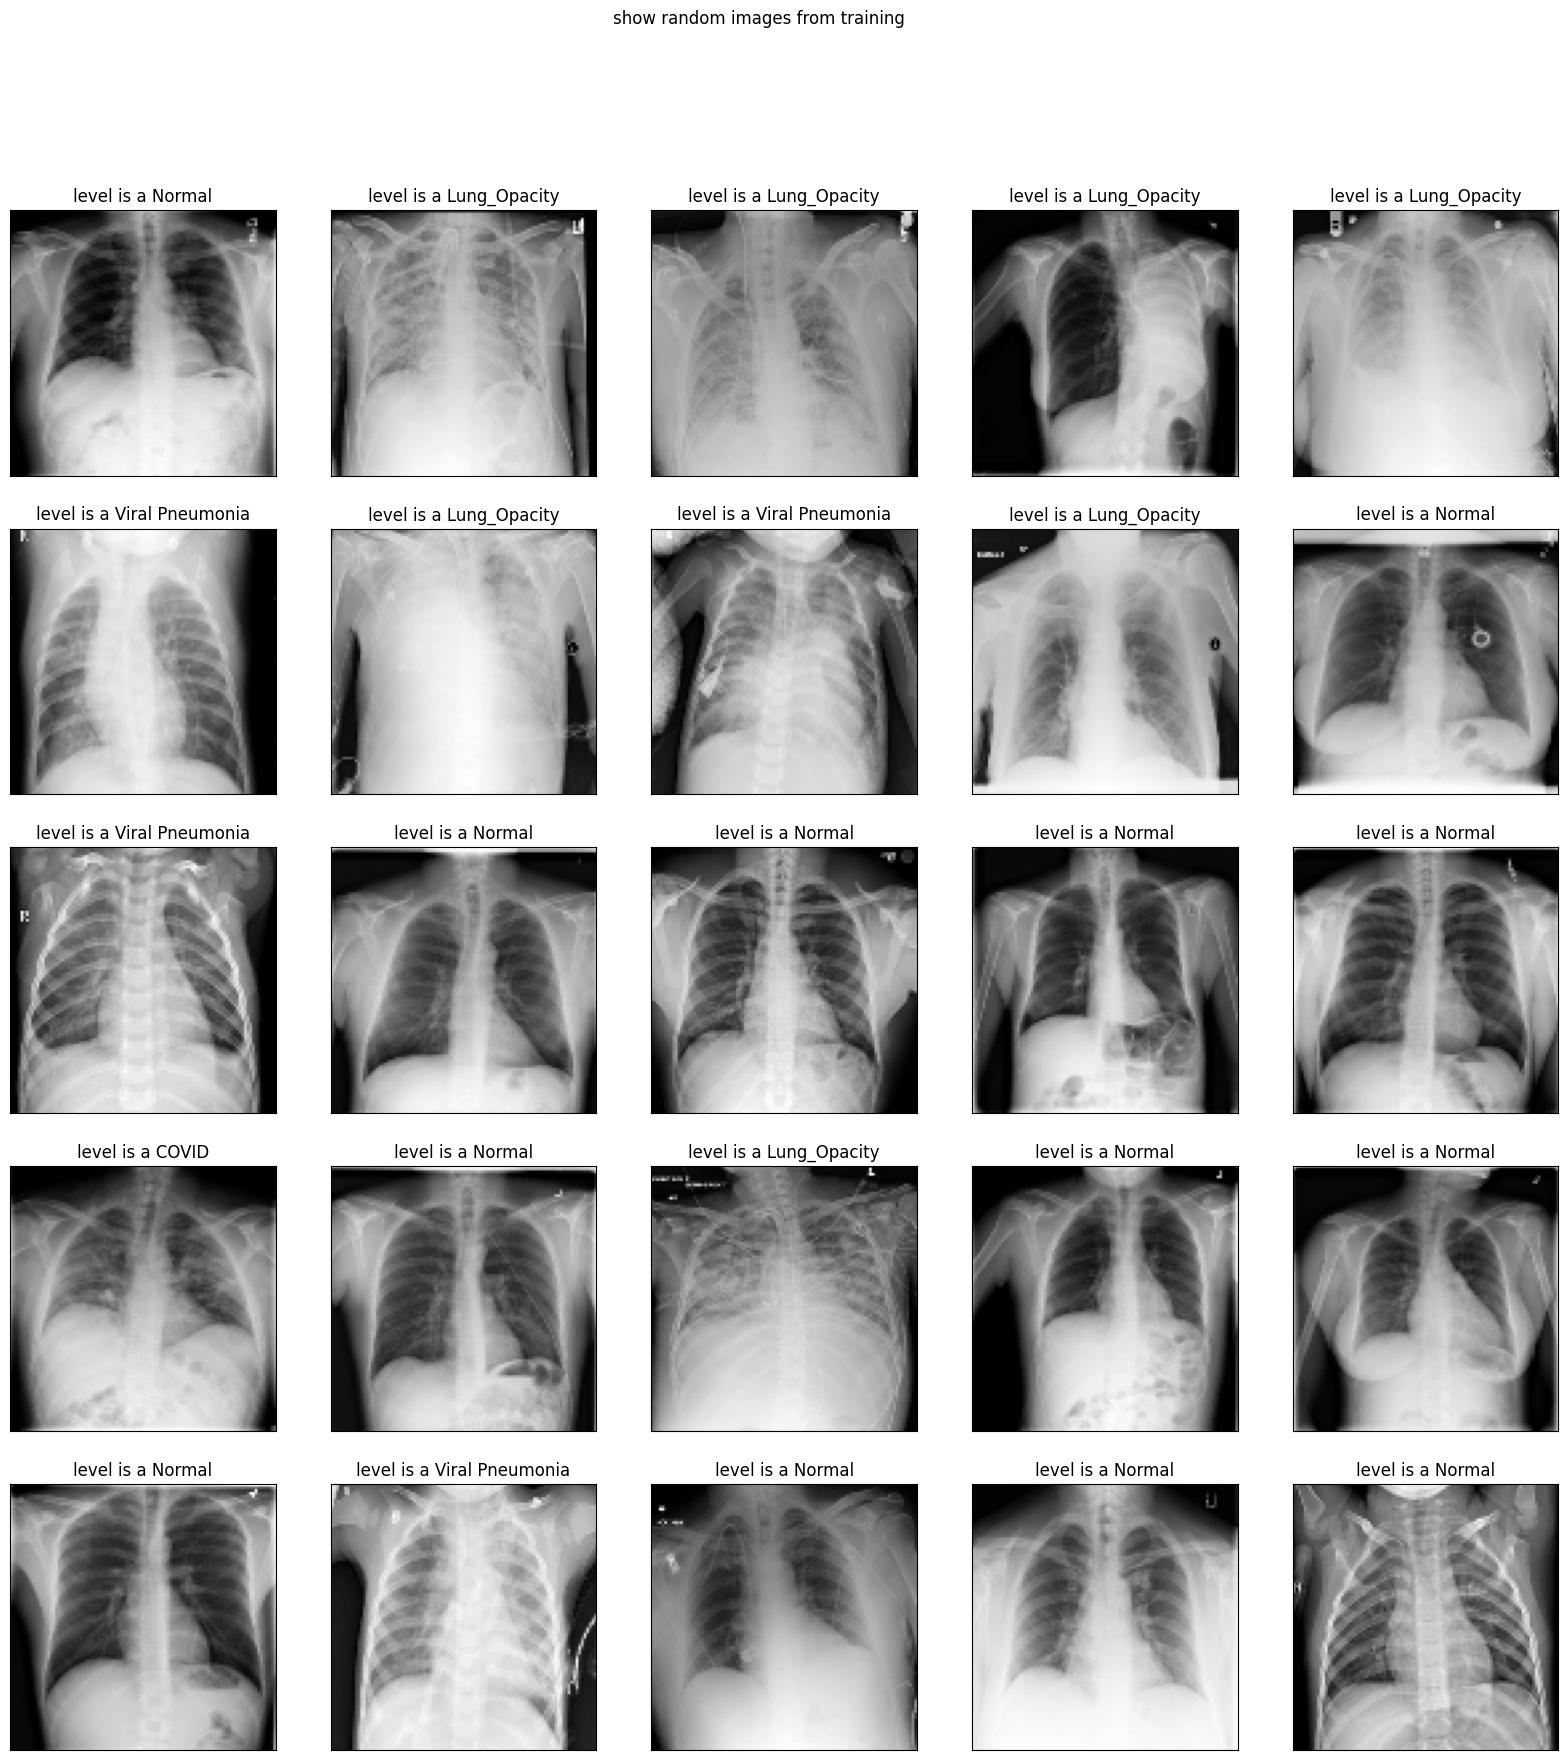

In [8]:
import matplotlib.pyplot as plt
levels = ['Normal', 'COVID', 'Lung_Opacity', 'Viral Pneumonia']
#show random images from train data set
def display_random_images(class_names,train_images,train_labels):
  fig=plt.figure(figsize=(20,20))
  fig.suptitle('show random images from training')
  for i in range(25):
    plt.subplot(5,5,i+1)
    plt.title(f'level is a {class_names[train_labels[i]]}')
    plt.imshow(train_images[i],cmap='gray')
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
  plt.show()
display_random_images(levels,train_images,train_labels)


In [9]:
#spliting test data to 10% test and 10% valdation
test_images,val_images,test_labels,val_labels=train_test_split(
    test_images,
    test_labels,
    test_size=0.5,
    random_state=42,
    shuffle=True
)
#show info about data
print(f'count train images : {train_images.shape}')
print(f'count train labels : {train_labels.shape}')
print(f'count val images : {val_images.shape}')
print(f'count val labels : {val_labels.shape}')
print(f'count test images : {test_images.shape}')
print(f'count test labels : {test_labels.shape}')

count train images : (16932, 100, 100, 1)
count train labels : (16932,)
count val images : (2117, 100, 100, 1)
count val labels : (2117,)
count test images : (2116, 100, 100, 1)
count test labels : (2116,)


In [10]:
!pip install tensorflow keras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 90.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 92.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.2/225.2 kB 21.5 MB/s eta 0:00:00


In [12]:
import tensorflow as tf
import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report


In [17]:
#arcteccher to cnn model fromscratch
model=models.Sequential([
  layers.Conv2D(32,(3,3),activation='relu',input_shape=(100,100,1)),
  layers.MaxPooling2D((2,2)),

  layers.Conv2D(64,(3,3),activation='relu'),
  layers.MaxPooling2D((2,2)),

  layers.Conv2D(128,(3,3),activation='relu'),
  layers.MaxPooling2D((2,2)),

  layers.Conv2D(64,(3,3),activation='relu'),
  layers.MaxPooling2D((2,2)),

  layers.Flatten(),#convert matrex to vector

  layers.Dense(128,activation='relu'),
  layers.Dropout(0.5),
  layers.Dense(4,activation='softmax')
]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
#fitting cnn model
model.fit(
    train_images,
    train_labels,
    batch_size=32,
    epochs=10,
    validation_data=(test_images, test_labels),
    callbacks=[
        EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        )
    ]

)

Epoch 1/10
530/530 ━━━━━━━━━━━━━━━━━━━━ 106s 197ms/step - accuracy: 0.5914 - loss: 0.9882 - val_accuracy: 0.7604 - val_loss: 0.6238
Epoch 2/10
530/530 ━━━━━━━━━━━━━━━━━━━━ 104s 196ms/step - accuracy: 0.7636 - loss: 0.6030 - val_accuracy: 0.8166 - val_loss: 0.4674
Epoch 3/10
530/530 ━━━━━━━━━━━━━━━━━━━━ 104s 196ms/step - accuracy: 0.8166 - loss: 0.4881 - val_accuracy: 0.8436 - val_loss: 0.3975
Epoch 4/10
530/530 ━━━━━━━━━━━━━━━━━━━━ 104s 196ms/step - accuracy: 0.8342 - loss: 0.4400 - val_accuracy: 0.8606 - val_loss: 0.3926
Epoch 5/10
530/530 ━━━━━━━━━━━━━━━━━━━━ 104s 195ms/step - accuracy: 0.8542 - loss: 0.3945 - val_accuracy: 0.8743 - val_loss: 0.3524
Epoch 6/10
530/530 ━━━━━━━━━━━━━━━━━━━━ 103s 195ms/step - accuracy: 0.8587 - loss: 0.3681 - val_accuracy: 0.8781 - val_loss: 0.3196
Epoch 7/10
530/530 ━━━━━━━━━━━━━━━━━━━━ 104s 196ms/step - accuracy: 0.8836 - loss: 0.3245 - val_accuracy: 0.8781 - val_loss: 0.3061
Epoch 8/10
530/530 ━━━━━━━━━━━━━━━━━━━━ 104s 196ms/step - accuracy: 0.8839 -

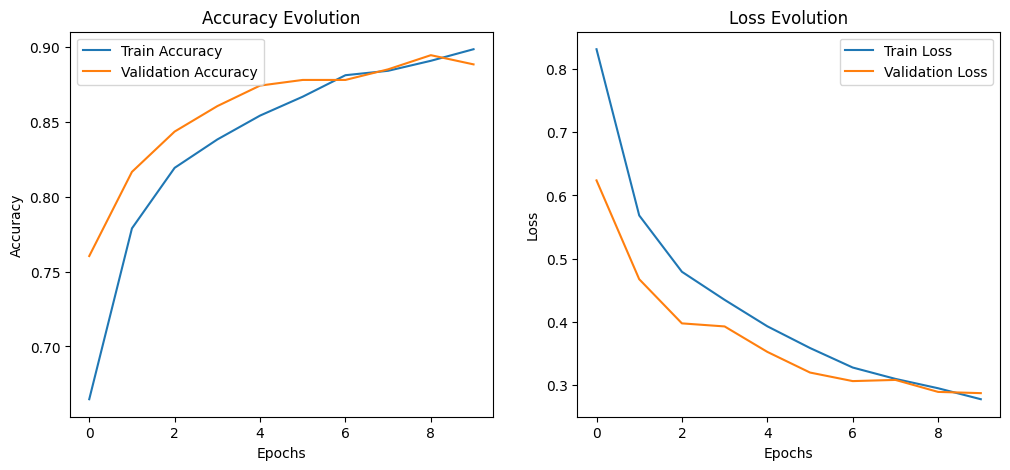

In [25]:
#display charts to accuracy and loss with epochs
plt.figure(figsize=(12, 5))
#chart to accuracy
plt.subplot(1, 2, 1)
plt.plot(model.history.history['accuracy'], label='Train Accuracy')
plt.plot(model.history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Evolution')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
#chart to loss
plt.subplot(1, 2, 2)
plt.plot(model.history.history['loss'], label='Train Loss')
plt.plot(model.history.history['val_loss'], label='Validation Loss')
plt.title('Loss Evolution')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [20]:
#model accuracy
test_loss, test_acc = model.evaluate(val_images, val_labels, verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}%")


 Test Accuracy: 87.95%


In [22]:
#model reporting
preds=model.predict(val_images)
pred_labels = np.argmax(preds, axis=1)
print(classification_report(val_labels, pred_labels))

67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step
              precision    recall  f1-score   support

           0       0.89      0.92      0.90      1025
           1       0.86      0.88      0.87       374
           2       0.86      0.80      0.83       582
           3       0.93      0.93      0.93       136

    accuracy                           0.88      2117
   macro avg       0.88      0.88      0.88      2117
weighted avg       0.88      0.88      0.88      2117

